# Coverage by Road Analysis

This notebook downloads the drivable street network for New York City using `osmnx`, buffers the street segments to create polygons, and then polyfills these polygons with H3 hexagons at resolution 12 using `h3-py`.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import shape
import matplotlib.pyplot as plt
import requests



## 1. Load Dashcam Metadata & Analyze Coverage

Load the Nexar dashcam dataset metadata and compare against the street network coverage.

In [2]:
# Load metadata
md_path = '../../data/processed/md.csv'
print(f"Loading dashcam metadata from {md_path}...")
df_md = pd.read_csv(md_path)

# Filter out invalid coordinates if any
df_md = df_md.dropna(subset=['gps_info.latitude', 'gps_info.longitude'])

print(f"Loaded {len(df_md)} dashcam records.")

Loading dashcam metadata from ../../data/processed/md.csv...
Loaded 926212 dashcam records.


## 2. Census Block & Block Group Analysis

Replicate the coverage analysis for Census Blocks (CB) and Census Block Groups (CBG) using the provided GeoJSON files.

In [3]:
def analyze_census_coverage(geojson_path, dashcam_df, name="Census Unit", network_gdf=None):
    print(f"\n--- Analyzing Coverage for {name} ---")
    
    # 1. Load Census Geometries
    print(f"Loading {name} from {geojson_path}...")
    gdf_census = gpd.read_file(geojson_path)
    print(f"Loaded {len(gdf_census)} features.")
    
    # 2. Determine 'Coverage' for Census Units
    # A census unit is 'covered' if it contains AT LEAST ONE dashcam image.
    # To do this efficiently:
    # Method A: Spatial Join (Point in Polygon)
    #   - Create GeoDataFrame of dashcam points
    #   - sjoin with census polygons
    #   - count images per census ID
    
    # Convert dashcam data to GeoDataFrame
    # Note: We already have df_md with lat/lon. Let's make a GDF.
    # Doing this for 900k points might be heavy but standard for spatial analysis.
    
    print("Creating Dashcam GeoDataFrame...")
    gdf_dashcam = gpd.GeoDataFrame(
        dashcam_df, 
        geometry=gpd.points_from_xy(dashcam_df['gps_info.longitude'], dashcam_df['gps_info.latitude']),
        crs="EPSG:4326"
    )
    
    # Ensure census data is in same CRS
    if gdf_census.crs != gdf_dashcam.crs:
        gdf_census = gdf_census.to_crs(gdf_dashcam.crs)
        
    # Filter by intersecting with street network if provided
    if network_gdf is not None:
        print("Filtering census units that intersect with buffered street network...")
        initial_count = len(gdf_census)
        
        # Ensure CRS match
        if network_gdf.crs != gdf_census.crs:
            network_gdf_local = network_gdf.to_crs(gdf_census.crs)
        else:
            network_gdf_local = network_gdf
            
        # Perform spatial join (inner) to keep only intersecting rows
        # We only need the geometry from network to save memory/time
        # We use sjoin with predicate='intersects'
        gdf_census = gpd.sjoin(gdf_census, network_gdf_local[['geometry']], how='inner', predicate='intersects')
        
        # Remove duplicates
        gdf_census = gdf_census[~gdf_census.index.duplicated(keep='first')]
        
        # Clean up sjoin columns
        if 'index_right' in gdf_census.columns:
            gdf_census = gdf_census.drop(columns=['index_right'])
            
        print(f"Filtered from {initial_count} to {len(gdf_census)} features.")
    
    print("Performing Spatial Join...")
    # sjoin: for each image, find which census polygon it falls into
    # op='within' is faster than 'intersects' for points
    joined = gpd.sjoin(gdf_dashcam, gdf_census, how="inner", predicate="within")
    
    # 3. Aggregate Counts
    # We assume the census file has a unique identifier. Usually 'GEOID' or 'BoroCT2020' etc.
    # Let's inspect columns if generic, but we'll guess or find the first unique ID.
    # Looking at standard NYC files, it's likely 'GEOID' or similar.
    # Let's try to find a likely ID column.
    possible_ids = ['GEOID', 'geoid', 'BoroCT2020', 'cb2020', 'boroct2020', 'gid', 'id']
    id_col = next((col for col in possible_ids if col in gdf_census.columns), gdf_census.columns[0])
    print(f"Using ID column: {id_col}")
    
    # Count images per ID
    counts = joined[id_col].value_counts()
    
    # Merge back to full census gdf to include those with 0 images
    gdf_coverage = gdf_census.merge(
        counts.rename('image_count'),
        left_on=id_col,
        right_index=True,
        how='left'
    )
    
    gdf_coverage['image_count'] = gdf_coverage['image_count'].fillna(0).astype(int)
    gdf_coverage['has_images'] = gdf_coverage['image_count'] > 0
    
    # 4. Statistics
    total = len(gdf_coverage)
    covered = gdf_coverage['has_images'].sum()
    not_covered = total - covered
    pct_covered = (covered / total) * 100
    
    print(f"Total {name}s: {total}")
    print(f"{name}s with Images: {covered} ({pct_covered:.2f}%)")
    print(f"{name}s without Images: {not_covered} ({100 - pct_covered:.2f}%)")
    
    return gdf_coverage, id_col



# Paths provided by user
CBG_PATH = "../../aggregation/geo/data/cbg-nyc-2020.geojson"
CB_PATH = "../../aggregation/geo/data/cb-nyc-2020.geojson"
CT_PATH = "../../aggregation/geo/data/ct-nyc-2020.geojson"

# Run Analysis
gdf_ct_cov, ct_id = analyze_census_coverage(CT_PATH, df_md, "Census Tract")
gdf_cbg_cov, cbg_id = analyze_census_coverage(CBG_PATH, df_md, "Census Block Group")
gdf_cb_cov, cb_id = analyze_census_coverage(CB_PATH, df_md, "Census Block")



--- Analyzing Coverage for Census Tract ---
Loading Census Tract from ../../aggregation/geo/data/ct-nyc-2020.geojson...
Loaded 2325 features.
Creating Dashcam GeoDataFrame...
Performing Spatial Join...
Using ID column: GEOID
Total Census Tracts: 2325
Census Tracts with Images: 2319 (99.74%)
Census Tracts without Images: 6 (0.26%)

--- Analyzing Coverage for Census Block Group ---
Loading Census Block Group from ../../aggregation/geo/data/cbg-nyc-2020.geojson...
Loaded 6807 features.
Creating Dashcam GeoDataFrame...
Performing Spatial Join...
Using ID column: GEOID
Total Census Block Groups: 6807
Census Block Groups with Images: 6592 (96.84%)
Census Block Groups without Images: 215 (3.16%)

--- Analyzing Coverage for Census Block ---
Loading Census Block from ../../aggregation/geo/data/cb-nyc-2020.geojson...
Loaded 37588 features.
Creating Dashcam GeoDataFrame...
Performing Spatial Join...
Using ID column: GEOID
Total Census Blocks: 37588
Census Blocks with Images: 32006 (85.15%)
Censu

## 10. Visualization of Census Coverage

Visualize the coverage maps for Census Block Groups and Census Blocks.

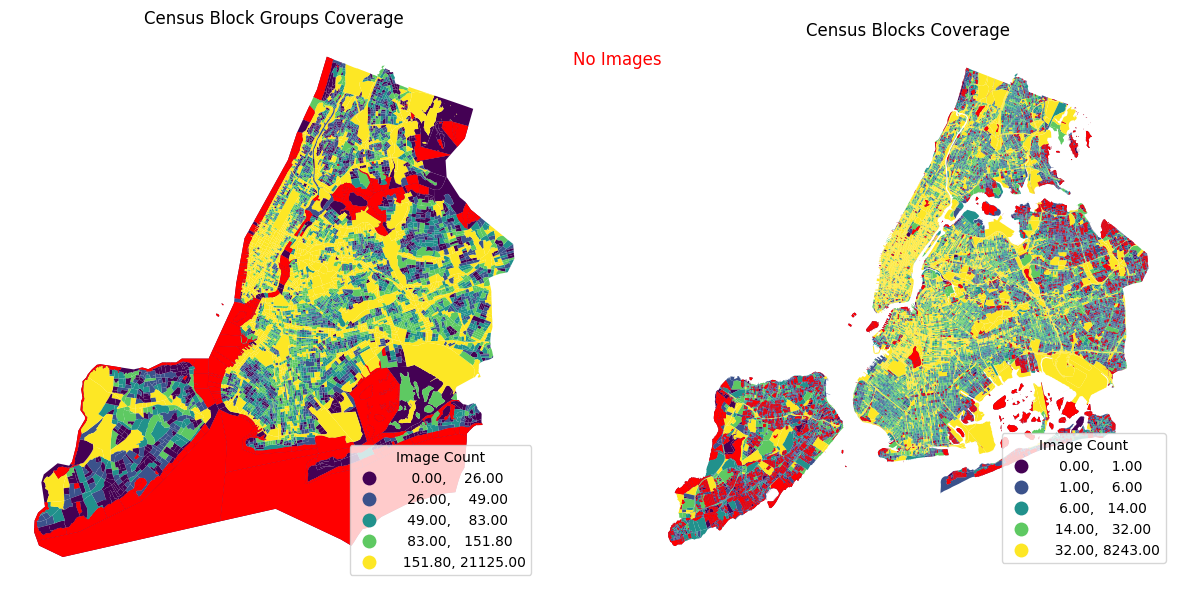

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot CBG
gdf_cbg_cov.plot(column='image_count', ax=axes[0], 
                 cmap='viridis', scheme='quantiles', k=5, 
                 legend=True, legend_kwds={'loc': 'lower right', 'title': 'Image Count'})
# fill the census block groups that have 0 images in red
gdf_cbg_cov.loc[gdf_cbg_cov['image_count'] == 0, 'no_images'] = 1
gdf_cbg_cov[gdf_cbg_cov['no_images'] == 1].plot(ax=axes[0], color='red', alpha=1)


axes[0].set_title("Census Block Groups Coverage")
axes[0].axis('off')

# Plot CB
gdf_cb_cov.plot(column='image_count', ax=axes[1], 
                cmap='viridis', scheme='quantiles', k=5, 
                legend=True, legend_kwds={'loc': 'lower right', 'title': 'Image Count'})
# fill the census blocks that have 0 images in red
gdf_cb_cov.loc[gdf_cb_cov['image_count'] == 0, 'no_images'] = 1
gdf_cb_cov[gdf_cb_cov['no_images'] == 1].plot(ax=axes[1], color='red', alpha=1)

axes[1].set_title("Census Blocks Coverage")
axes[1].axis('off')

# add text box to the top center of the plot 
text_box = plt.text(1.15, 0.95, 'No Images', ha='center', va='center', fontsize=12, color='red', transform=axes[0].transAxes)
plt.show()

In [5]:
thresholds = [1, 5, 10, 20, 50, 100, 500, 5000]
summary_data = []

geometries = [
    ("Tracts", gdf_ct_cov),
    ("Block Groups", gdf_cbg_cov),
    ("Blocks", gdf_cb_cov)
]

for name, gdf in geometries:
    total = len(gdf)
    row = {"Census Unit": name}
    for t in thresholds:
        count = (gdf['image_count'] >= t).sum()
        pct = (count / total) * 100
        row[fr"$\geq {t}$"] = fr"{pct:.2f}\%"
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary

,Census Unit,$\geq 1$,$\geq 5$,$\geq 10$,$\geq 20$,$\geq 50$,$\geq 100$,$\geq 500$,$\geq 5000$
0,Tracts,99.74\%,99.66\%,99.44\%,98.67\%,94.45\%,80.99\%,21.55\%,0.22\%
1,Block Groups,96.84\%,95.09\%,92.35\%,85.18\%,59.54\%,32.82\%,4.80\%,0.04\%
2,Blocks,85.15\%,65.48\%,49.26\%,30.95\%,12.25\%,4.71\%,0.16\%,0.01\%


In [ ]:
import constants as c
from pathlib import Path
PAPER_PATH = Path(c.PAPER_PATH)
with open(PAPER_PATH / "tables" / "census_coverage_summary.tex", "w") as f:
    f.write(df_summary.to_latex(index=False, 
                                  caption="Percentage of census geometries with minimum image counts", 
                                  label="tab:hyperlocal_census_coverage",
                                  column_format="l" + "r" * len(thresholds)))

print(f"Summary table saved to {PAPER_PATH / 'tables' / 'census_coverage_summary.tex'}")

Summary table saved to /share/ju/matt/bayflood/papers/natcities_bayflood_2025/tables/census_coverage_summary.tex


## 11. Spatial Spread within Census Tracts

Calculate the percentage of Census Block Groups within each Census Tract that have at least one image, and find the median across all tracts.

In [8]:
# Analysis of spatial spread within tracts
# Map each CBG to its parent Census Tract (first 11 digits of GEOID)
gdf_cbg_cov['ct_geoid'] = gdf_cbg_cov[cbg_id].astype(str).str[:11]

# Group by Census Tract and calculate coverage percentage
tract_stats = gdf_cbg_cov.groupby('ct_geoid').agg(
    total_cbgs=('has_images', 'count'),
    covered_cbgs=('has_images', 'sum')
)
tract_stats['pct_covered'] = (tract_stats['covered_cbgs'] / tract_stats['total_cbgs']) * 100

median_tract_cbg_coverage = tract_stats['pct_covered'].median()

# Updated print statement for more context
mean_tract_cbg_coverage = tract_stats['pct_covered'].mean()
num_100_pct_tracts = (tract_stats['pct_covered'] == 100).sum()
pct_100_pct_tracts = (num_100_pct_tracts / len(tract_stats)) * 100

print(f"Within the median Census tract, {median_tract_cbg_coverage:.2f}% of the Census block groups within it had at least one image.")
print(f"Mean tract-level CBG coverage: {mean_tract_cbg_coverage:.2f}%")
print(f"Percentage of tracts with 100% CBG coverage: {pct_100_pct_tracts:.2f}%")

Within the median Census tract, 100.00% of the Census block groups within it had at least one image.
Mean tract-level CBG coverage: 97.29%
Percentage of tracts with 100% CBG coverage: 91.79%
